# Data preparation for Llama
Stage 2 & 3

## A Overview

In [2]:
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split

import configuration

from src import hf_utils, setup
from src.models import bert

/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
datasets_path = Path("..") / "data"/"splitted"
df_predictions = pd.read_csv(datasets_path / "llama_pre_bert_sets_with_predictions.csv")
df_predictions.shape


/tmp/ipykernel_18096/3266600920.py:2: DtypeWarning: Columns (0: humanitarian_label) have mixed types. Specify dtype option on import or set low_memory=False.
  df_predictions = pd.read_csv(datasets_path / "llama_pre_bert_sets_with_predictions.csv")


(2933542, 7)

In [4]:
df_failed_predictions = df_predictions[df_predictions["informative"] != df_predictions["predicted"]]
print(df_failed_predictions.shape)
df_failed_predictions.head()

(73699, 7)


,uid,tweet_text,informative,humanitarian_label,subset,predicted,confidence
3,178535,"If I have a specialization, what can i do to f...",True,not_humanitarian,disaster,0,0.921999
4,168358,Talking to my cousin right now from Nepal he's...,False,not_related_or_irrelevant,disaster,1,0.570526
8,229637,RT @HighvTweet: Empire State Buildings lit up ...,False,not_humanitarian,disaster,1,0.930152
12,131246,Production of winter fodder (wheat straw) will...,True,other_relevant_information,disaster,0,0.551669
26,217232,http://t.co/6ezlEVGnCI Congrats to PNoy &amp; ...,False,not_related_or_irrelevant,disaster,1,0.918786


/tmp/ipykernel_18096/3323271711.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Informative")


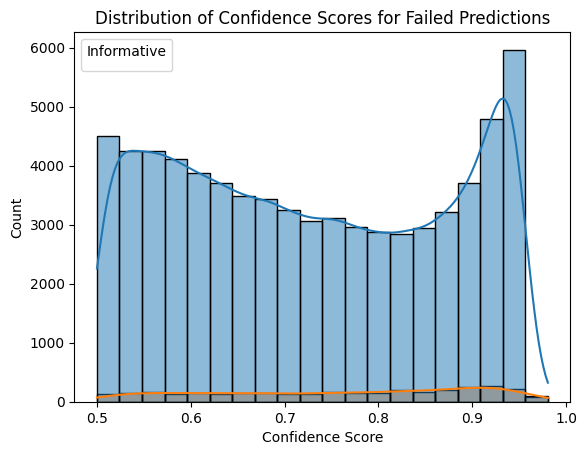

In [ ]:
# plotting the distribution of confidence scores by class for failed predictions
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=df_failed_predictions, x="confidence", hue="informative", bins=20, kde=True)
plt.title("Distribution of Confidence Scores for Failed Predictions")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.legend(title="Informative")
plt.show()


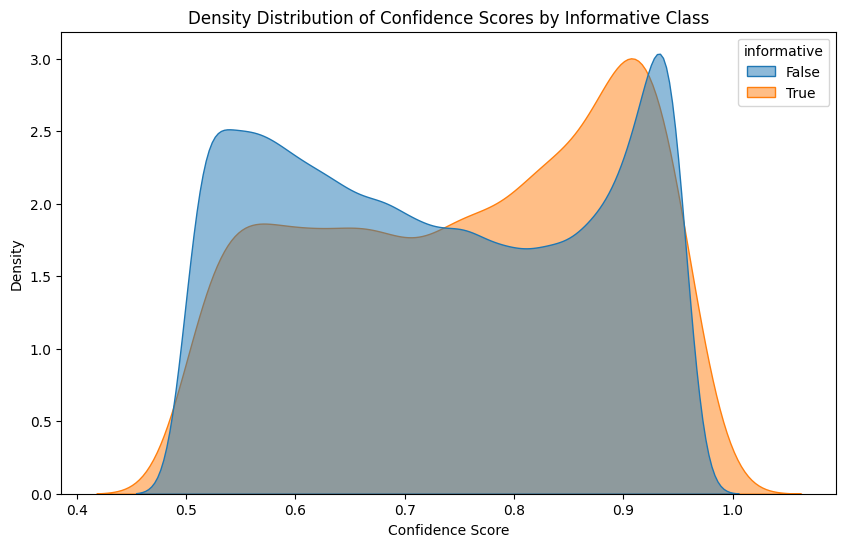

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# common_norm=False ensures each class's density is scaled independently
sns.kdeplot(
    data=df_failed_predictions, 
    x="confidence", 
    hue="informative", 
    fill=True, 
    common_norm=False, 
    alpha=0.5
)
plt.title("Density Distribution of Confidence Scores by Informative Class")
plt.xlabel("Confidence Score")
plt.ylabel("Density")
plt.show()

/tmp/ipykernel_18096/1872297451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


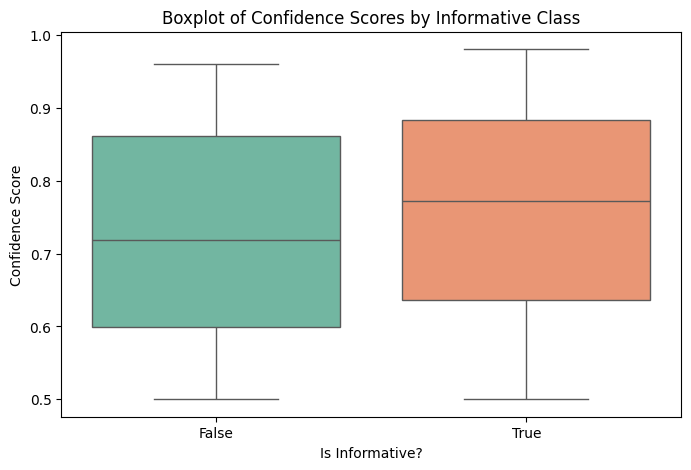

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_failed_predictions, 
    x="informative", 
    y="confidence",
    palette="Set2"
)
plt.title("Boxplot of Confidence Scores by Informative Class")
plt.xlabel("Is Informative?")
plt.ylabel("Confidence Score")
plt.show()

In [16]:
threshold = 0.55
df_low_confidence = df_predictions[df_predictions["confidence"] < threshold]
df_low_confidence.head()

,uid,tweet_text,informative,humanitarian_label,subset,predicted,confidence
63,144887,I need help walking Daryl in the next 36 hours...,False,not_humanitarian,disaster,1,0.521170
129,32613,Truly Armageddon. Jose Andres is on the ground...,True,rescue_volunteering_or_donation_effort,disaster,1,0.505365
182,213728,it was great to have people vaccinated at silv...,True,other_relevant_information,disaster,0,0.548808
194,42193,[SisLovesMe] Moka Mora - Hush Hush Big Brother...,False,not_humanitarian,disaster,1,0.533128
240,205,"Meeting Olivier, Sebastien and Antoine of Beer...",False,not_related_or_irrelevant,disaster,0,0.515604


In [18]:
df_low_confidence.shape

(20210, 7)

In [17]:
df = pd.read_csv(datasets_path / "llama_set.csv")
print(df.shape)

(73699, 7)
